# DOD Particle Lab — Analysis

Loads every collected run under `experiments/data/<layout>/*/runs.csv`, joins the
hardware sidecar (`hardware.json`) on `machine_id`, and produces the per-layout
champion grid + the performance landscapes. **No global winner** (§16.9):
every champion declaration carries regime + numbers + blueprint.

Re-run after dropping in runs from new machines:
```
.venv/bin/jupyter nbconvert --execute --to notebook --inplace experiments/results/analyze.ipynb
```

In [1]:
import glob, json, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

if os.path.isdir('experiments/data'):
    DATA_GLOB = 'experiments/data/*/*/runs.csv'
    HW_GLOB   = 'experiments/data/*/*/hardware.json'
    PMC_GLOB  = 'experiments/data/*/*/pmc_rollup.csv'
else:
    DATA_GLOB = '../data/*/*/runs.csv'
    HW_GLOB   = '../data/*/*/hardware.json'
    PMC_GLOB  = '../data/*/*/pmc_rollup.csv'

mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

## 1. Load runs + hardware

In [2]:
rows = []
for p in sorted(glob.glob(DATA_GLOB)):
    df = pd.read_csv(p)
    df['source_file'] = p
    rows.append(df)
runs = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

hw_rows = []
for p in sorted(glob.glob(HW_GLOB)):
    with open(p) as f: hw_rows.append(json.load(f))
hw = pd.DataFrame(hw_rows).drop_duplicates('machine_id') if hw_rows else pd.DataFrame()

# PMC rollups (optional, Mac+Xcode)
pmc_rows = []
for p in sorted(glob.glob(PMC_GLOB)):
    df = pd.read_csv(p)
    df['source_file'] = p
    pmc_rows.append(df)
pmc = pd.concat(pmc_rows, ignore_index=True) if pmc_rows else pd.DataFrame()

n_rows = len(runs)
n_machines = runs['machine_id'].nunique() if n_rows else 0
n_cells = runs['cell'].nunique() if n_rows else 0
print(f'loaded {n_rows} rows from {len(rows)} run dirs '
      f'across {n_machines} machine(s), {n_cells} cell(s)')
if n_rows:
    print('machines:', ', '.join(sorted(runs['machine_id'].unique())))
    print('cells   :', ', '.join(sorted(runs['cell'].unique())))
    print(f'PMC data: {len(pmc)} rows from {len(pmc_rows)} run(s)')

loaded 4 rows from 1 run dirs across 1 machine(s), 2 cell(s)
machines: minibits-b7641c0e
cells   : L1.B1.w1-autovec.w2-opt, L1.B1.w1-autovec.w2-simple
PMC data: 0 rows from 0 run(s)


## 2. Tidy + reduce (min per (cell, mode, death_q, N) across trials)

In [3]:
if n_rows:
    for c in ['ns_frame','ns_particle','bytes_per_particle']:
        runs[c] = pd.to_numeric(runs[c], errors='coerce')
    runs['death_q'] = pd.to_numeric(runs['death_q'])
    runs['cell_short'] = runs['cell'].str.replace(r'^L\d+\.', '', regex=True)
    # achieved bandwidth = bytes/p * N / frame_time (the hot-loop bandwidth)
    runs['achieved_bw_gbs'] = runs['bytes_per_particle'] * runs['N'] / runs['ns_frame']

    key = ['machine_id','cell','mode','death_q','N']
    mins = (runs.sort_values('ns_frame')
             .groupby(key, as_index=False).first()
             [['machine_id','cell','cell_short','mode','death_q','N',
               'bytes_per_particle','ns_frame','ns_particle','achieved_bw_gbs']])
else:
    mins = pd.DataFrame()
print(f'{len(mins)} reduced rows (min-of-trials)')

4 reduced rows (min-of-trials)


## 3. Performance landscapes — ns/particle vs N (faceted by death_q)

One subplot per death_q; one curve per cell. Lower is better.

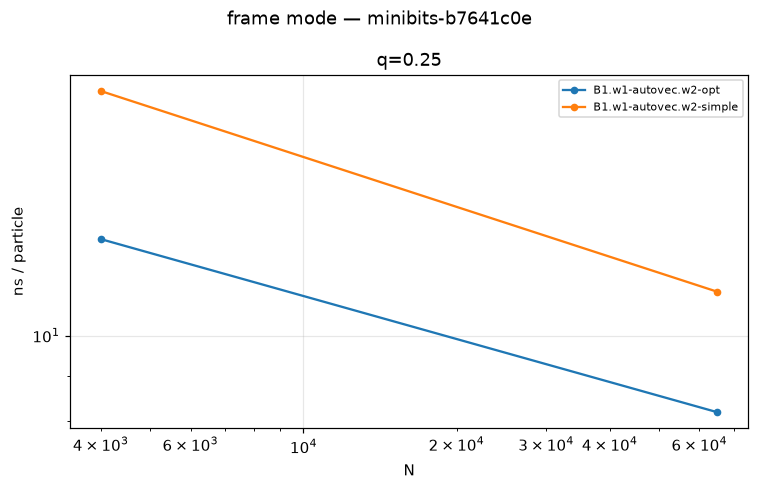

In [4]:
if len(mins):
    for (mid, mode), g in mins.groupby(['machine_id','mode']):
        rates = sorted(g['death_q'].unique())
        n_rates = len(rates)
        if n_rates == 1:
            fig, ax = plt.subplots(figsize=(7,4.5))
            axes = [ax]
        else:
            fig, axes = plt.subplots(1, n_rates, figsize=(5*n_rates, 4.5), sharey=True)
        for ax, q in zip(axes, rates):
            gg = g[g['death_q'] == q]
            for cell, cg in gg.groupby('cell_short', sort=False):
                cg = cg.sort_values('N')
                ax.plot(cg['N'], cg['ns_particle'], 'o-', label=cell, ms=4)
            ax.set_xscale('log'); ax.set_yscale('log')
            ax.set_xlabel('N'); ax.set_title(f'q={q}')
            if q == rates[0]: ax.set_ylabel('ns / particle')
        axes[0].legend(fontsize=7, loc='best')
        fig.suptitle(f'{mode} mode — {mid}')
        fig.tight_layout(); plt.show()
else:
    print('no data — run scripts/collect.sh first')

## 4. Achieved bandwidth vs the streaming ceiling

`achieved_bw = bytes/p × N / frame_time` compared to the machine's measured
single-core streaming ceiling (`streaming_bw_gbs` in `hardware.json`). Near the
ceiling = bandwidth-bound; well below = compute/latency-bound.

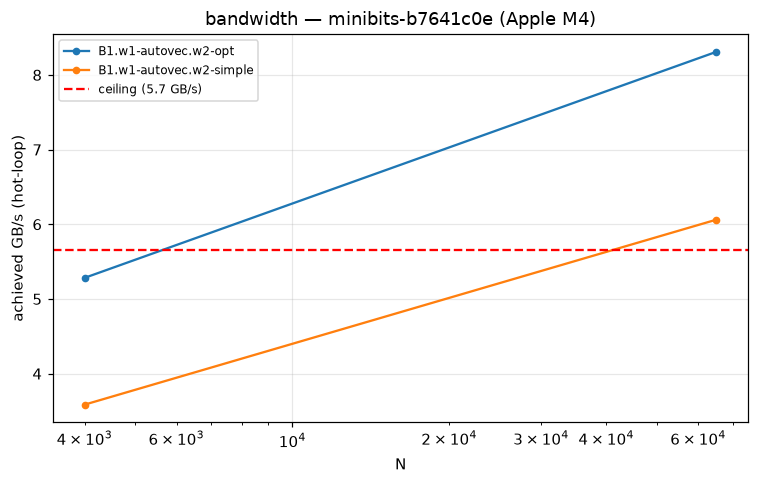

In [5]:
if len(mins) and len(hw):
    step = mins.merge(hw[['machine_id','cpu','streaming_bw_gbs']], on='machine_id')
    for mid, g in step.groupby('machine_id'):
        ceiling = g['streaming_bw_gbs'].iloc[0]
        fig, ax = plt.subplots(figsize=(7,4.5))
        for cell, cg in g.groupby('cell_short', sort=False):
            cg = cg.sort_values('N')
            ax.plot(cg['N'], cg['achieved_bw_gbs'], 'o-', label=cell, ms=4)
        ax.axhline(ceiling, color='r', ls='--', label=f'ceiling ({ceiling:.1f} GB/s)')
        ax.set_xscale('log')
        ax.set_xlabel('N'); ax.set_ylabel('achieved GB/s (hot-loop)')
        ax.set_title(f'bandwidth — {mid} ({g["cpu"].iloc[0]})')
        ax.legend(fontsize=8, loc='best')
        fig.tight_layout(); plt.show()
else:
    print('no data — run scripts/collect.sh first')

## 5. Champion grid (Table C) — per regime, per death_q

Best cell per regime (small ≤65K / mid 262K–1M / large ≥4M) per death_q.
No global winner — champions are regime + numbers + cell.

In [6]:
def regime(n):
    if n <= 65_000: return 'small (<=65K)'
    if n <= 1_000_000: return 'mid (262K-1M)'
    return 'large (>=4M)'

if len(mins):
    mins2 = mins.assign(regime=mins['N'].map(regime))
    champs = (mins2.sort_values('ns_frame')
              .groupby(['machine_id','mode','regime','death_q'], as_index=False).first()
              [['machine_id','mode','regime','death_q','cell_short','N','ns_frame',
                'ns_particle','achieved_bw_gbs']])
    for (mid, mode), g in champs.groupby(['machine_id','mode']):
        print(f'\n=== champions: {mid} / {mode} ===')
        print(g[['regime','death_q','cell_short','N','ns_frame','ns_particle','achieved_bw_gbs']]
              .to_string(index=False))
else:
    print('no data — run scripts/collect.sh first')


=== champions: minibits-b7641c0e / frame ===
       regime  death_q           cell_short    N  ns_frame  ns_particle  achieved_bw_gbs
small (<=65K)     0.25 B1.w1-autovec.w2-opt 4000   51487.1      12.8718         5.282877


## 6. Cross-machine comparison

Overlay the same cell across machines. A layout win on one machine can be a
wash on another (different cache sizes, different DRAM BW).

In [7]:
if len(mins) and mins['machine_id'].nunique() > 1:
    for mode, g in mins.groupby('mode'):
        for cell, cg in g.groupby('cell_short', sort=False):
            fig, ax = plt.subplots(figsize=(7,4.5))
            for mid, mg in cg.groupby('machine_id'):
                mg = mg.sort_values('N')
                ax.plot(mg['N'], mg['ns_particle'], 'o-', label=mid, ms=4)
            ax.set_xscale('log'); ax.set_yscale('log')
            ax.set_xlabel('N'); ax.set_ylabel('ns / particle')
            ax.set_title(f'{cell} — {mode} (across machines)')
            ax.legend(fontsize=8, loc='best')
            fig.tight_layout(); plt.show()
elif len(mins):
    print(f'only one machine so far ({sorted(mins["machine_id"].unique())[0]}); '
          'collect on another to see the cross-machine view')

only one machine so far (minibits-b7641c0e); collect on another to see the cross-machine view


## 7. PMC cycle-attribution (when present)

The bottleneck breakdown (useful / frontend / backend / branch) behind each
cell's bandwidth/compute-bound result. Joins on `(machine_id, cell, N)`.
Absent on non-Mac or Mac without Xcode — this section skips gracefully.

In [8]:
if len(pmc):
    print(f'PMC data: {len(pmc)} rows from {pmc["machine_id"].nunique()} machine(s)')
    print(pmc.head())
else:
    print('no PMC data (run scripts/pmc_sweep.sh on a Mac with Xcode)')

no PMC data (run scripts/pmc_sweep.sh on a Mac with Xcode)


## 8. Hardware facts (per machine)

In [9]:
if len(hw):
    cols = [c for c in ['machine_id','cpu','physicalcpu','logicalcpu',
                        'l1dcachesize','l2cachesize','l3cachesize',
                        'cachelinesize','memsize_bytes','streaming_bw_gbs','os','arch']
            if c in hw.columns]
    print(hw[cols].to_string(index=False))
else:
    print('no hardware sidecars found')

       machine_id      cpu  physicalcpu  logicalcpu  l1dcachesize  l2cachesize  l3cachesize  cachelinesize  memsize_bytes  streaming_bw_gbs            os  arch
minibits-b7641c0e Apple M4           10          10         65536      4194304            0            128    17179869184              5.66 Darwin 25.5.0 arm64
